# ROC

In [1]:
import json
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [2]:
def get_statistic_scores(model_name, filename_tested):         
    
    filename_scores = f"evaluation_area/{model_name}/{filename_tested}.json"
    with open(filename_scores, "r", encoding="utf-8") as file:
        data_scores = json.load(file)
        y_score = [x[0] for x in data_scores]
        y_true = [x[1] for x in data_scores]
        
    filename_model_info_training =  f"evaluation_area/_trainings_overview.json"
    with open(filename_model_info_training, "r", encoding="utf-8") as trainingfile:
        data_info_model = json.load(trainingfile)        
        for model in data_info_model:
            if model == model_name:
                model_info_training = data_info_model[model_name]        
    
    return y_score, y_true, model_info_training

In [3]:
def build_roc_curve(model_names, filename_tested, colors):
    plt.figure()

    legend_entries = []

    for model in model_names:
        y_score, y_true, model_info_training = get_statistic_scores(model_name = model, filename_tested=filename_tested)
        
        fpr, tpr, thresholds = roc_curve(y_true=y_true, y_score=y_score, pos_label='1')
        roc_auc = auc(fpr,tpr)

        color = colors.pop()
        plt.plot(fpr, tpr, color=color, lw=2)
        legend_entries.append(f'ROC {model} (area = {roc_auc:.2f}) {model_info_training}')
        
        plt.plot(fpr, tpr, color=color, lw=2, label=f'ROC {model} (area = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Testdata: {filename_tested}')
    plt.legend(loc="lower right")
    plt.figtext(0.5, -0.1, "\n".join(legend_entries), wrap=True, horizontalalignment='center', fontsize=10)
    plt.savefig(f"roc_{model}-{filename_tested}.svg", format="svg", bbox_inches="tight")
    plt.show()

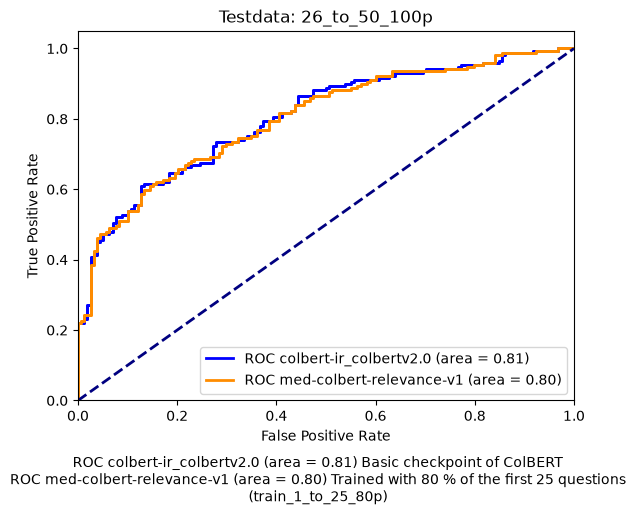

In [4]:
build_roc_curve(model_names = ['colbert-ir_colbertv2.0', 'med-colbert-relevance-v1'], 
                filename_tested = '26_to_50_100p',
                colors=['red', 'darkorange', 'blue'])

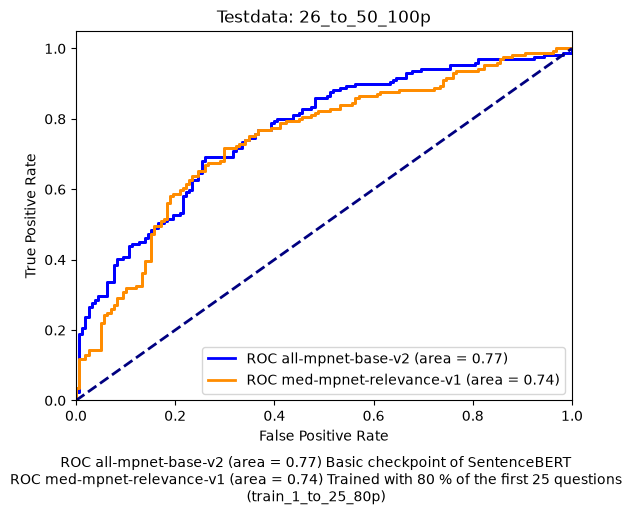

In [5]:
build_roc_curve(model_names = ['all-mpnet-base-v2', 'med-mpnet-relevance-v1'], 
                filename_tested = '26_to_50_100p',
                colors=['red', 'darkorange', 'blue'])

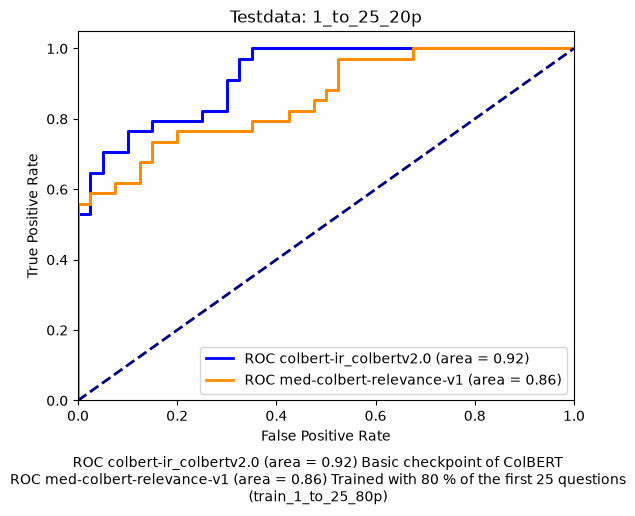

In [6]:
build_roc_curve(model_names = ['colbert-ir_colbertv2.0', 'med-colbert-relevance-v1'], 
                filename_tested = '1_to_25_20p',
                colors=['red', 'darkorange', 'blue'])

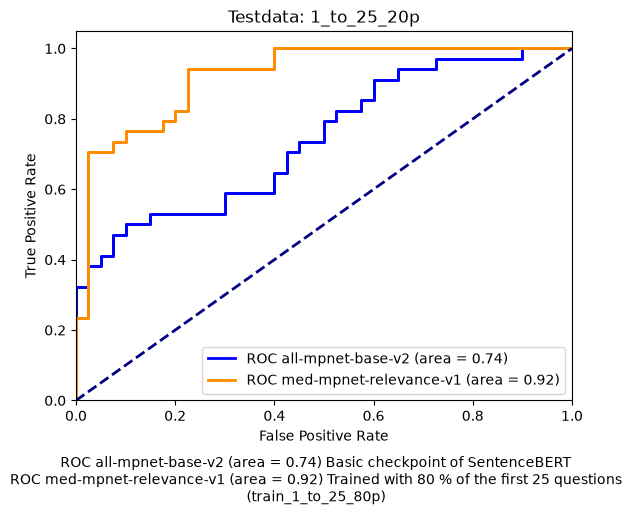

In [7]:
build_roc_curve(model_names = ['all-mpnet-base-v2', 'med-mpnet-relevance-v1'], 
                filename_tested = '1_to_25_20p',
                colors=['red', 'darkorange', 'blue'])

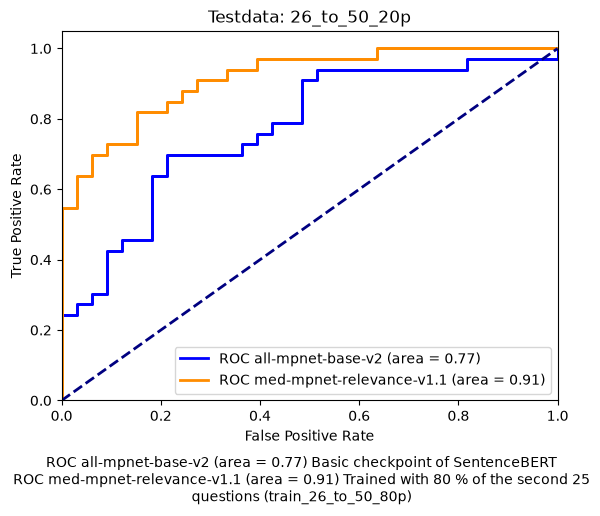

In [8]:
build_roc_curve(model_names = ['all-mpnet-base-v2', 'med-mpnet-relevance-v1.1'], 
                filename_tested = '26_to_50_20p',
                colors=['red', 'darkorange', 'blue'])

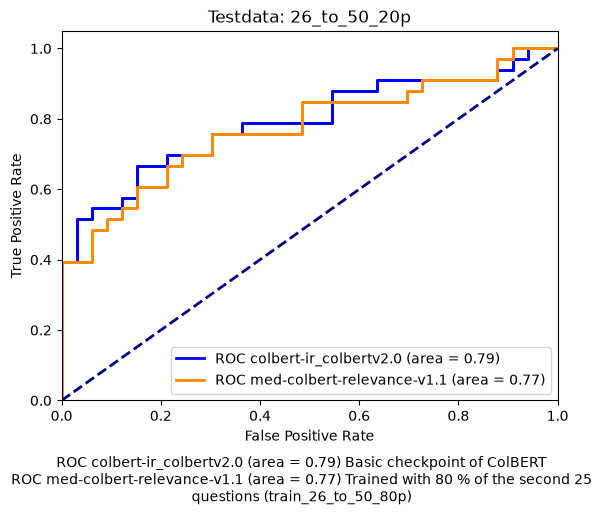

In [9]:
build_roc_curve(model_names = ['colbert-ir_colbertv2.0', 'med-colbert-relevance-v1.1'], 
                filename_tested = '26_to_50_20p',
                colors=['red', 'darkorange', 'blue'])

# Boxplot

In [10]:
import seaborn as sns
import numpy as np

# Prepare data for the boxplot
# y_bool = [0, 1, 0, 1, 1, 0, 1, 0, 1, 0]
# y_scores = [0.2, 0.8, 0.4, 0.9, 0.85, 0.1, 0.6, 0.3, 0.75, 0.05]

def build_boxplot(model, filename_tested, ylimbot, ylimtop):    

    y_score, y_true, model_info_training = get_statistic_scores(model_name = model,                                                                 
                                                                filename_tested=filename_tested)    
    
    y_true = np.array([int(i) for i in y_true])
    y_score = np.array(y_score)
    scores_by_class = [y_score[y_true == 0], y_score[y_true == 1]] 
      
    plt.figure(figsize=(0.5, 6))
    sns.boxplot(data=scores_by_class)
    plt.xticks([0, 1], labels=['Irrelevant', 'Relevant'], rotation=45, ha='right', fontsize=11)    
    plt.ylabel('Predicted Scores')       
    plt.ylim(ylimbot, ylimtop)
    plt.title(model, fontsize=10, fontweight = 'bold', pad=15)
    plt.figtext(1, -0.2, f'Tested:  {filename_tested} \n\n Trained: {model_info_training}', wrap=True, horizontalalignment='center', fontsize=10)
    plt.savefig(f"bp_{model}-{filename_tested}.svg", format="svg", bbox_inches="tight")
    plt.show()

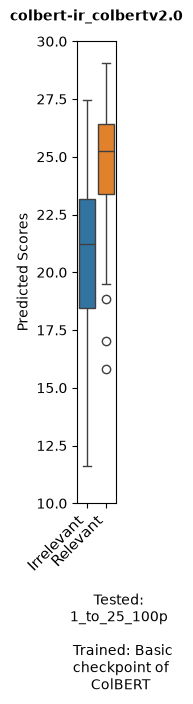

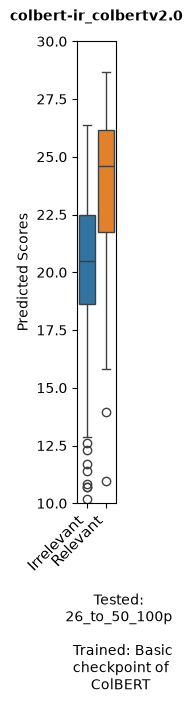

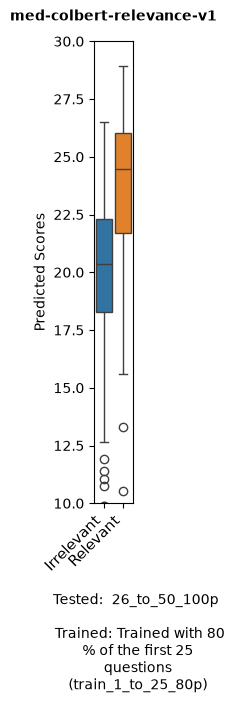

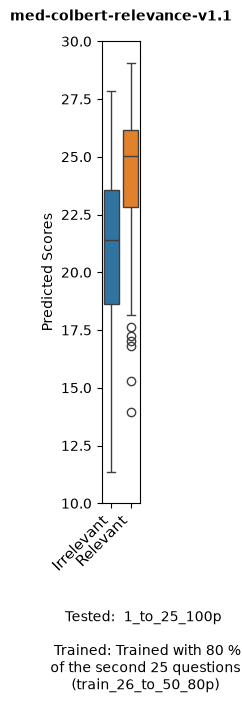

In [11]:
ylimitertop = 30
ylimiterbottom = 10
build_boxplot('colbert-ir_colbertv2.0', '1_to_25_100p', ylimiterbottom, ylimitertop)
build_boxplot('colbert-ir_colbertv2.0', '26_to_50_100p', ylimiterbottom, ylimitertop)
build_boxplot('med-colbert-relevance-v1', '26_to_50_100p', ylimiterbottom, ylimitertop)
build_boxplot('med-colbert-relevance-v1.1', '1_to_25_100p', ylimiterbottom, ylimitertop)

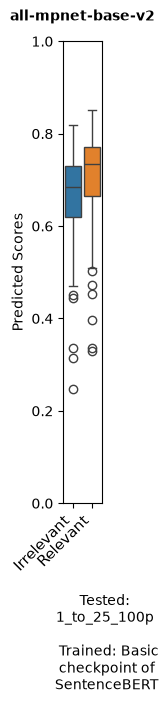

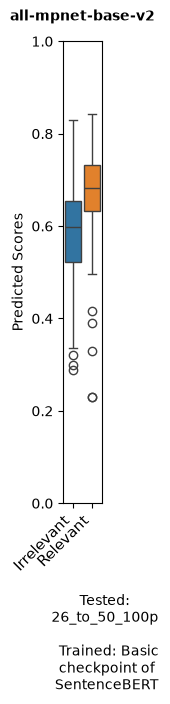

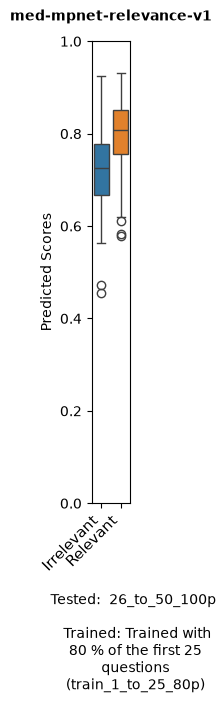

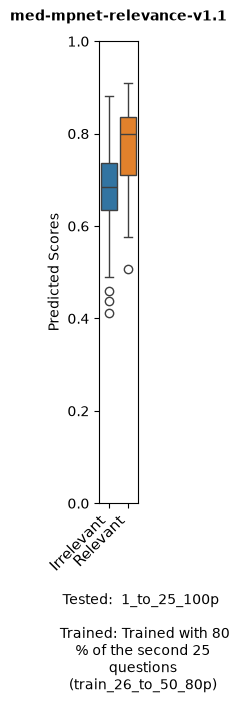

In [12]:
build_boxplot('all-mpnet-base-v2', '1_to_25_100p', 0,1 )
build_boxplot('all-mpnet-base-v2', '26_to_50_100p', 0,1)
build_boxplot('med-mpnet-relevance-v1', '26_to_50_100p', 0,1)
build_boxplot('med-mpnet-relevance-v1.1', '1_to_25_100p', 0,1)

In [13]:
def load_testdata_and_model_scores(test_set, model):
    test_path = f"test_splits/test_{test_set}.json"
    test_data = json.load(open(test_path))

    print(f'Testdata loaded: {test_path}')

    model_score_path = f'evaluation_area/{model}/{test_set}.json'
    model_scores_data = json.load(open(model_score_path))

    print(f'Model: {model}')
    print(f'Path: Model Score Data: {model_score_path}')
    print(f'Number of entries: {len(model_scores_data)}')

    # Check whether the number of test data points and scores match
    if len(test_data) != len(model_scores_data):
        print(f'WARNING: Number of testdata ({len(test_data)}) != Number of scores ({len(model_scores_data)})')

    # Check whether the relevance scores of the test data match the relevance scores in the model scores
    for i in range(len(test_data)):
        if test_data[i][2] != model_scores_data[i][1]:
            print(f'WARNING: Testdata and Model-Scores are not equivalent at index {i}:')

    return test_data, model_scores_data

In [14]:
def load_testdata_and_model_scores_grouped_by_document(test_set, model):
    test_data, model_scores_data = load_testdata_and_model_scores(test_set, model)

    # Merging Test Data and Model Scores
    relevance_score = []
    model_score =[]
    for i in range(len(test_data)):

        # Check whether the relevance scores of the test data match the relevance scores in the model scores
        if test_data[i][2] != model_scores_data[i][1]:
            print(f'WARNING: Testdata and Model-Scores are not equivalent at index  {i}:')

        # Extract Question ID, Document ID, Relevance Rating, and Model Score
        question_id = test_data[i][0]
        document_id = test_data[i][1]
        relevance_score.append(test_data[i][2])
        model_score.append(model_scores_data[i][0]) 

    
    relevance_score = np.array(relevance_score)
    model_score = np.array(model_score)

    return relevance_score, model_score


In [15]:
COMBINATIONS = [['all-mpnet-base-v2', 'med-mpnet-relevance-v1', '1_to_25_20p'],
                    ['colbert-ir_colbertv2.0', 'med-colbert-relevance-v1', '1_to_25_20p'], 
                    ['all-mpnet-base-v2', 'med-mpnet-relevance-v1.1', '26_to_50_20p'],
                    ['colbert-ir_colbertv2.0', 'med-colbert-relevance-v1.1', '26_to_50_20p'],
                    ['all-mpnet-base-v2', 'med-mpnet-relevance-v1.1', '1_to_25_100p'],
                    ['colbert-ir_colbertv2.0', 'med-colbert-relevance-v1.1', '1_to_25_100p'],
                    ['all-mpnet-base-v2', 'med-mpnet-relevance-v1', '26_to_50_100p'],
                    ['colbert-ir_colbertv2.0', 'med-colbert-relevance-v1', '26_to_50_100p']]
                     

In [16]:
import numpy as np
from sklearn.metrics import roc_auc_score

all_models_all_values = []
for kombination in COMBINATIONS:
    model1, model2, test_set = kombination
    print(f"Compare: {model1} vs {model2} on testset {test_set}")
    relevance_base, y_score_base = load_testdata_and_model_scores_grouped_by_document(test_set, model1)
    relevance_base, y_score_ft = load_testdata_and_model_scores_grouped_by_document(test_set, model2)    
    y_true = relevance_base

    mean_A = roc_auc_score(relevance_base, y_score_base)
    mean_B = roc_auc_score(relevance_base, y_score_ft)

    observed_diff =  mean_B - mean_A

    # ==========================================
    #  BOOTSTRAP INITIALIZATION
    # ==========================================
    rng = np.random.default_rng(seed=42)
    n_bootstraps = 1000 
    indices = np.arange(len(y_true))

    bootstrap_aucs_A = np.zeros(n_bootstraps)
    bootstrap_aucs_B = np.zeros(n_bootstraps)
    bootstrap_diffs_ci = np.zeros(n_bootstraps)
    bootstrap_diffs_p = np.zeros(n_bootstraps)

    # ==========================================
    #  RESAMPLING Loop
    # ==========================================
    for i in range(n_bootstraps):
        # Get Random Indices
        boot_indices = rng.choice(indices, size=len(y_true), replace=True)
        
        # Extract a sample for this run
        y_true_boot = y_true[boot_indices]
        
        # Ensure that both classes are represented in the sample
        if len(np.unique(y_true_boot)) < 2:
            continue
            
        scores_A_boot = y_score_base[boot_indices]
        scores_B_boot = y_score_ft[boot_indices]
        
        # Calculate AUCs for this run
        boot_auc_A = roc_auc_score(y_true_boot, scores_A_boot)
        boot_auc_B = roc_auc_score(y_true_boot, scores_B_boot)
        
                
        # 3a. For the confidence interval (original difference)
        bootstrap_aucs_A[i] = boot_auc_A
        bootstrap_aucs_B[i] = boot_auc_B
        bootstrap_diffs_ci[i] = boot_auc_B - boot_auc_A


    # ==========================================
    #  Evaluation
    # ==========================================
    

    # 95%-CI für Model A
    ci_A_lower = np.percentile(bootstrap_aucs_A, 2.5)
    ci_A_upper = np.percentile(bootstrap_aucs_A, 97.5)

    # 95%-CI für Model B
    ci_B_lower = np.percentile(bootstrap_aucs_B, 2.5)
    ci_B_upper = np.percentile(bootstrap_aucs_B, 97.5)

    # 95% Confidence Interval (Percentile Method)
    ci_lower = np.percentile(bootstrap_diffs_ci, 2.5)
    ci_upper = np.percentile(bootstrap_diffs_ci, 97.5)

    print(f"Original AUC Model A:    {mean_A:.4f}")
    print(f"Model A AUC: {mean_A:.4f}  |  95%-CI: [{ci_A_lower:.4f}, {ci_A_upper:.4f}]")

    print(f"Original AUC Model B:    {mean_B:.4f}")
    print(f"Model B AUC: {mean_B:.4f}  |  95%-CI: [{ci_B_lower:.4f}, {ci_B_upper:.4f}]")

    print(f"Difference B - A:    {observed_diff:.4f}")    
    print(f"95%-Confidence:     [{ci_lower:.4f}, {ci_upper:.4f}]")
    print(f"="*100)
    
    significant = "*" if (ci_lower * ci_upper) > 0 else "ns"   
   

    all_models_all_values.append(f'{model2} & {mean_B:.2f}[{ci_B_lower:.2f}, {ci_B_upper:.2f}] / {mean_A:.2f}[{ci_A_lower:.2f}, {ci_A_upper:.2f}] & {observed_diff:.2f}[{ci_lower:.2f}, {ci_upper:.2f}] & {significant} \\')
    

Compare: all-mpnet-base-v2 vs med-mpnet-relevance-v1 on testset 1_to_25_20p
Testdata loaded: test_splits/test_1_to_25_20p.json
Model: all-mpnet-base-v2
Path: Model Score Data: evaluation_area/all-mpnet-base-v2/1_to_25_20p.json
Number of entries: 74
Testdata loaded: test_splits/test_1_to_25_20p.json
Model: med-mpnet-relevance-v1
Path: Model Score Data: evaluation_area/med-mpnet-relevance-v1/1_to_25_20p.json
Number of entries: 74
Original AUC Model A:    0.7419
Model A AUC: 0.7419  |  95%-CI: [0.6249, 0.8523]
Original AUC Model B:    0.9221
Model B AUC: 0.9221  |  95%-CI: [0.8523, 0.9708]
Difference B - A:    0.1801
95%-Confidence:     [0.0580, 0.3001]
Compare: colbert-ir_colbertv2.0 vs med-colbert-relevance-v1 on testset 1_to_25_20p
Testdata loaded: test_splits/test_1_to_25_20p.json
Model: colbert-ir_colbertv2.0
Path: Model Score Data: evaluation_area/colbert-ir_colbertv2.0/1_to_25_20p.json
Number of entries: 74
Testdata loaded: test_splits/test_1_to_25_20p.json
Model: med-colbert-relev

In [17]:
all_models_all_values

for lines in all_models_all_values:
    print(f"{lines}\\")

med-mpnet-relevance-v1 & 0.92[0.85, 0.97] / 0.74[0.62, 0.85] & 0.18[0.06, 0.30] & * \\
med-colbert-relevance-v1 & 0.86[0.77, 0.93] / 0.92[0.86, 0.97] & -0.06[-0.11, -0.03] & * \\
med-mpnet-relevance-v1.1 & 0.91[0.84, 0.97] / 0.77[0.66, 0.88] & 0.14[0.04, 0.26] & * \\
med-colbert-relevance-v1.1 & 0.77[0.65, 0.88] / 0.79[0.67, 0.89] & -0.02[-0.05, 0.01] & ns \\
med-mpnet-relevance-v1.1 & 0.79[0.74, 0.84] / 0.66[0.60, 0.72] & 0.13[0.07, 0.19] & * \\
med-colbert-relevance-v1.1 & 0.79[0.74, 0.83] / 0.85[0.81, 0.89] & -0.07[-0.08, -0.05] & * \\
med-mpnet-relevance-v1 & 0.74[0.68, 0.79] / 0.77[0.72, 0.82] & -0.03[-0.09, 0.04] & ns \\
med-colbert-relevance-v1 & 0.80[0.76, 0.85] / 0.81[0.76, 0.85] & -0.00[-0.01, 0.00] & ns \\
